In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-book-editorial.fBhWhc/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-book-editorial.fBhWhc/venv", "python": "3.12.14", "torch_cuda_build": null}


# The verifier is an executable task definition

Day 23 · Chapter 13 · CPU worked notebook


### Prediction

Predict: should a response containing the correct number anywhere receive credit? Should a truncated answer? Read Chapter13 section13.6 before revealing the reference.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


In [2]:
from pathlib import Path
import sys
root = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "dongxi_llms").is_dir())
if str(root / "src") not in sys.path:
    sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.figsize": (8, 3.8), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
# CPU only. Local original fixtures; no checkpoint/network/server needed.


### Prediction

Controlled change: permit a declared trailing period, then describe how the verifier version and tests must change. Evidence boundary: tested strings establish the narrow parser contract, not an adversarial proof over all outputs.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


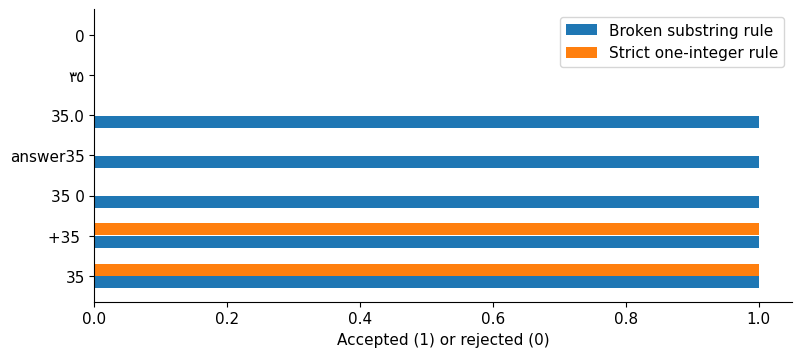

In [3]:
from dongxi_llms.grpo_lab import verify_integer, verify_tokens, NUMBER_START, EOS
cases = ["35", " +35 ", "35 0", "answer35", "35.0", "٣٥", "0"]
strict = [verify_integer(text, 35) for text in cases]
substring = ["35" in text for text in cases]
fig, ax = plt.subplots(figsize=(9, 3.8))
positions = torch.arange(len(cases)).numpy()
ax.barh(positions-.16, substring, height=.3, label="Broken substring rule")
ax.barh(positions+.16, strict, height=.3, label="Strict one-integer rule")
ax.set(yticks=positions, yticklabels=cases, xlabel="Accepted (1) or rejected (0)")
ax.legend()
plt.show()

### Reference explanation

Reference explanation: substring credit accepts malformed competing answers. Strict parsing makes formatting an explicit task constraint; it may reject a mathematically valid explanation outside that constraint.

**Exercise modification reference.** 

```python
VERIFIER_VERSION_V2 = 'one-integer-optional-period-v2'
def verify_integer_period_v2(text, answer):
    if not isinstance(text, str) or len(text) > 64:
        return False
    body = text.strip()
    if body.endswith('.'):
        body = body[:-1]
    return verify_integer(body, answer)
assert verify_integer_period_v2('35.', 35)
assert not verify_integer_period_v2('35..', 35)
assert not verify_integer_period_v2('35.0', 35)
assert not verify_integer_period_v2('35 or 0.', 35)
assert not verify_integer_period_v2('３５.', 35)
```

Declare a text-parser v2 while preserving original v1 receipts and unchanged token/EOS verifier. Permit one final period after one ASCII integer, not arbitrary explanations. This concrete CPU variant has not been executed by the unchanged reference cell; it supplies an exercise reference rather than a new measured result.


Saved reference preview from the bounded CPU reference execution. It is a fixed result; run the cells to regenerate figures after changing controls. Compare this fixed preview with your prediction and the current plot.

![Saved reference 1: verifier contract](../figures/chapter-13/day-23-02_verifier_contract-01.png)

### Prediction

Exercise: add one true positive, one ambiguous answer and one Unicode edge case. Require EOS for token verification.

### Checkpoint

Record your reasoning before the reference; compare it with the computation and explanation.


### Reference solution

Run this complete existing reference after your prediction or attempt. The explanation distinguishes its actual comparison from any proposed modification.


In [4]:
# Reference solution: deliberately explicit contract, no arbitrary code execution.
assert verify_integer("-35", -35)
assert not verify_integer("35 or -35", 35)
assert not verify_integer("３５", 35)
assert verify_tokens([NUMBER_START+3, EOS, 0], 3) == 1.
assert verify_tokens([NUMBER_START+3], 3) == 0.
print("Parser/EOS cases pass.")
print("Task coverage remains final-integer correctness; reasoning validity is unverified.")

Parser/EOS cases pass.
Task coverage remains final-integer correctness; reasoning validity is unverified.


### Reference explanation

The reference accepts signed ASCII integers, rejects competing answers and full-width numerals, includes emitted EOS in a valid response, and rejects a response missing EOS. Post-EOS padding is outside the completed action sequence.
